In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
exodata = pd.read_csv("exoplanet_data.csv",comment = "#")
# print(exodata)
print(exodata.shape,exodata.keys())#564 rows, 92 cols
#idk what: ttv_flag pl_radj hostname ra dec are
# Find the following Table Labels with their associated variable names:
# Planet Name - pl_name† - Planet name most commonly used in the literature
# Host Name - hostname† - Stellar name most commonly used in the literature
# Discovery Method - discoverymethod† - Method by which the planet was first identified
# Spectral Type - st_spectype - Classification of the star based on their spectral characteristics following the Morgan-Keenan system
# Equilibrium Temperature [K] - pl_eqt† - The equilibrium temperature of the planet as modeled by a black body heated only by its host star, or for directly imaged planets, the effective temperature of the planet required to match the measured luminosity if the planet were a black body
# Planet Mass or Mass*sin(i) [Jupiter Mass] - pl_bmassj† -  - Best planet mass estimate available, in order of preference: Mass, M*sin(i)/sin(i), or M*sin(i), depending on availability, and measured in Jupiter masses 

(564, 92) Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 's

In [3]:
smalldata = exodata[["pl_name","hostname","discoverymethod","st_spectype","pl_eqt","pl_bmassj"]]
smalldata = smalldata[smalldata.isnull().any(axis=1)]
print(smalldata.shape,smalldata.head(5),smalldata.tail(5),smalldata.keys())#497 rows, 6 cols
print(smalldata["discoverymethod"].value_counts())
#there are 7 methods, transit has the most disk kinematics has the least
#transit is checking for the slight dimming of a star when a planet goes in front of it
#radial velocity check for planet "wobble"
#microlensing look at tons of stars for short brightening
#imaging checking for actual pieces of the planet
#transit timing variations look for variations in expected timing of planets
#eclipse timing variations above but for their eclipses
#disk kinematics look for diff in the way the planet is supposed to move?

(497, 6)        pl_name  hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
0      7 CMa c     7 CMa  Radial Velocity         NaN     NaN   0.912000
1      7 CMa c     7 CMa  Radial Velocity         NaN     NaN   0.870000
8   DMPP-3 A b  DMPP-3 A  Radial Velocity         NaN  854.00   0.008118
9   DS Tuc A b  DS Tuc A          Transit         NaN  836.71        NaN
10  DS Tuc A b  DS Tuc A          Transit        G6 V  850.00        NaN          pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
558       XO-7 b       XO-7          Transit        G0 V     NaN        NaN
559    bet Pic c    bet Pic  Radial Velocity         NaN     NaN      9.000
560    bet Pic c    bet Pic  Radial Velocity         NaN  1250.0      8.200
561    bet Pic c    bet Pic  Radial Velocity         NaN     NaN     10.139
562  eps Ind A b  eps Ind A  Radial Velocity        K2 V     NaN      3.250 Index(['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt',
       'pl_bmassj'],
  

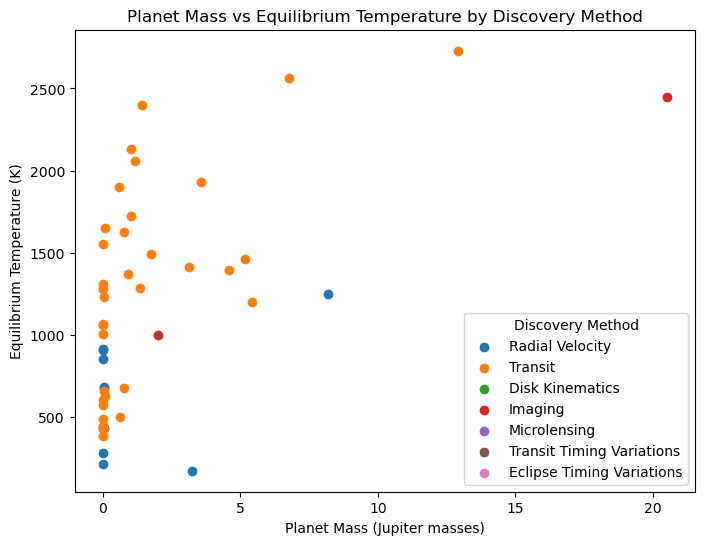

In [4]:
fig = plt.figure(figsize=(8,6))
methods = smalldata["discoverymethod"].unique()
if len(methods) > 0:
    for method in methods:
        checkmeth = smalldata["discoverymethod"] == method
        plt.scatter(smalldata.loc[checkmeth, "pl_bmassj"], smalldata.loc[checkmeth, "pl_eqt"], label=method)

plt.xlabel("Planet Mass (Jupiter masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.legend(title="Discovery Method")
plt.title("Planet Mass vs Equilibrium Temperature by Discovery Method")
plt.show()

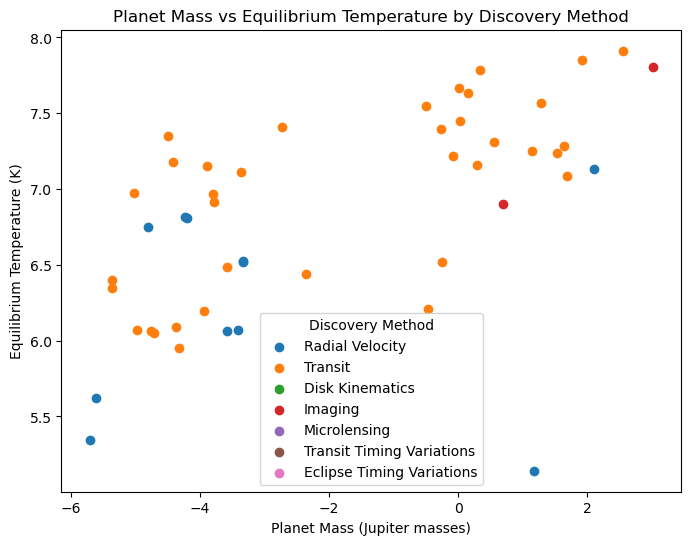

In [5]:
fig = plt.figure(figsize=(8,6))
methods = smalldata["discoverymethod"].unique()
if len(methods) > 0:
    for method in methods:
        checkmeth = smalldata["discoverymethod"] == method
        plt.scatter(np.log(smalldata.loc[checkmeth, "pl_bmassj"]),np.log(smalldata.loc[checkmeth, "pl_eqt"]), label=method)

plt.xlabel("Planet Mass (Jupiter masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.legend(title="Discovery Method")
plt.title("Planet Mass vs Equilibrium Temperature by Discovery Method")
plt.show()

In [6]:
heavyplanets = smalldata[smalldata["pl_bmassj"]>5]
coldest=np.min(heavyplanets["pl_eqt"])
coldindex=np.argmin(heavyplanets["pl_eqt"])
print(coldest,coldindex,heavyplanets.iloc[coldindex])
#name is TOI-172 b, it's at the 24th index, temp is 1198K, mass is 5.42, it says null for spectral type

1198.0 24 pl_name            TOI-172 b
hostname             TOI-172
discoverymethod      Transit
st_spectype              NaN
pl_eqt                1198.0
pl_bmassj               5.42
Name: 447, dtype: object


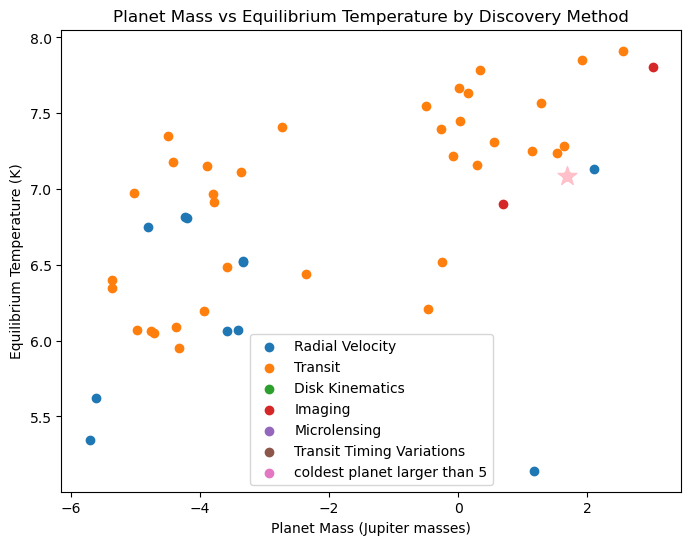

In [7]:
fig = plt.figure(figsize=(8,6))
methods = smalldata["discoverymethod"].unique()
if len(methods) > 0:
    for method in methods:
        checkmeth = smalldata["discoverymethod"] == method
        plt.scatter(np.log(smalldata.loc[checkmeth, "pl_bmassj"]),np.log(smalldata.loc[checkmeth, "pl_eqt"]), label=method)

plt.scatter(
    np.log(5.42),
    np.log(coldest),
    color="pink",
    marker='*',
    s=200
)
labels = smalldata["discoverymethod"].unique()
labels[-1]="coldest planet larger than 5"
plt.xlabel("Planet Mass (Jupiter masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.legend(labels)
plt.title("Planet Mass vs Equilibrium Temperature by Discovery Method")
plt.show()

In [8]:
#title="A temperate super-Jupiter imaged with JWST in the mid-infrared"
#there's a new really big planet that can be found with imaging
#my ans was different
#my planet is supposed to be the coldest planet larger than 5 jupiters
#my planet doesn't match the temp or mass of the one found in the paper
#temp diff of 923k and idk the mass from the paper